In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as imbPipeline

sns.set(style="whitegrid")

## 1. EDA

1.1 Data exploration

In [20]:
df = pd.read_csv("data.csv", sep=';')

In [21]:
#Data Set observation

print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [23]:
#Counting number of nan values for each feature

print(df.isna().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [24]:
#Data observation for integer features

num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].describe()



,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


#### 1.2 Data Vizualization

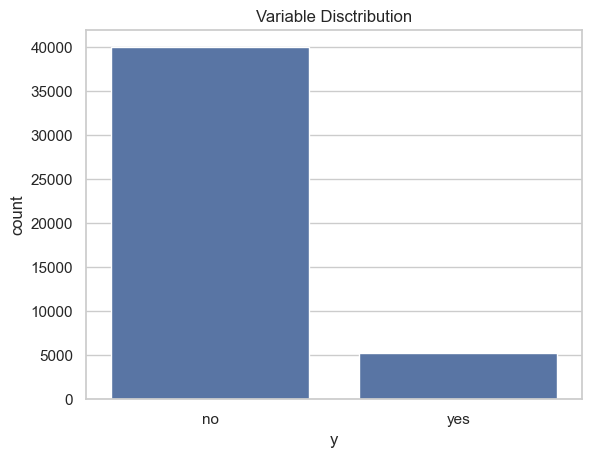

In [25]:
#Disctribution of all target values in dataset
sns.countplot(x='y', data=df)
plt.title('Variable Disctribution')
plt.show()

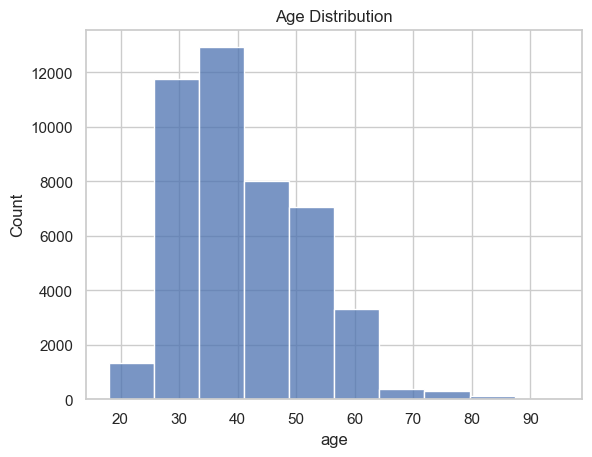

In [26]:
sns.histplot(df['age'], bins=10)
plt.title('Age Distribution')
plt.show()

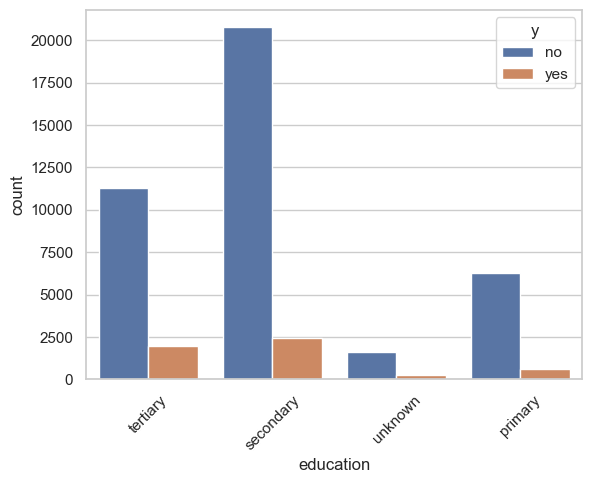

In [27]:
#Comparing of all education levels by target value

sns.countplot(x='education', hue='y', data=df)
plt.xticks(rotation=45)
plt.show()

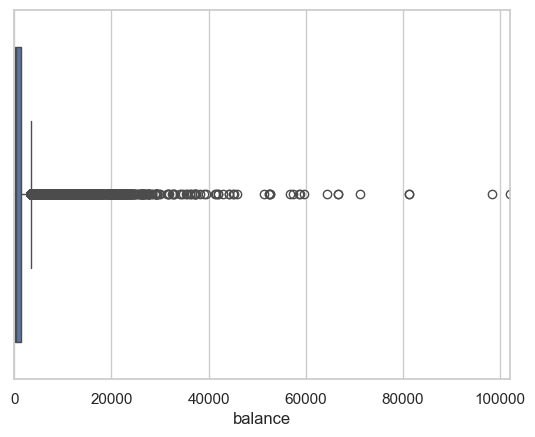

In [28]:
sns.boxplot(x=df['balance'])
plt.xlim(0, df['balance'].max())
plt.show()

#### 1.3 Correlation Analysis

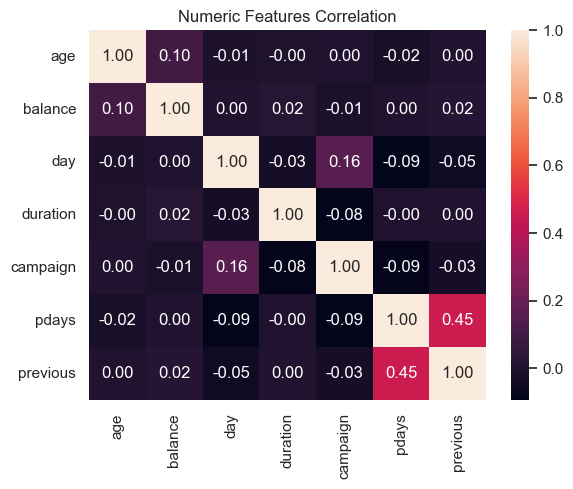

In [29]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title("Numeric Features Correlation")
plt.show()

## 2. Data processing/engineering ##

In [30]:
cat_cols = df.select_dtypes(include=['object']).drop(columns=['y']).columns

In [31]:
def create_prep():
    num_transformer = Pipeline(steps=[('scaler', StandardScaler())])

    cat_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

    prep = ColumnTransformer(transformers=[('num', num_transformer, num_cols),
                                           ('cat', cat_transformer, cat_cols)])
    return prep

preprocessor = create_prep()



According to some observations we did data exploratory analysis and feature engineering engineering(Standardize data and Encoding)

## 3. Model Building (Построение моделей)

#### 3.1 Logistic Regression

In [32]:
X = df.drop(columns='y', axis=1)


Y = (df['y'] == 'yes').astype(int)
#Y = df['y'].map({'yes': 1, 'no' : 0})

In [33]:
Xtrain, Ytrain, Xtest, Ytest = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [34]:
pipe = imbPipeline(steps=[
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('logreg',LogisticRegression(random_state=42, max_iter=1000))
])

pipe.fit(Xtrain, Ytrain)

Ypred = pipe.predict(Xtest)
Yprob = pipe.predict_proba(Xtest)[:, 1]

TypeError: '<' not supported between instances of 'str' and 'int'

In [35]:
# 1. Преобразуем Xtrain
Xtrain_enc = preprocessor.fit_transform(Xtrain)
Xtest_enc  = preprocessor.transform(Xtest)

# 2. Применяем SMOTE к уже числовому Xtrain_enc
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(Xtrain_enc, Ytrain)

# 3. Обучаем модель
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_res, y_res)

# 4. Делаем предсказания
Ypred = clf.predict(Xtest_enc)
Yprob = clf.predict_proba(Xtest_enc)[:, 1]


ValueError: X does not contain any features, but ColumnTransformer is expecting 16 features

Your comments here:

#### 3.2 Decision Tree

Your comments here:

#### 3.3 Random Forest

Your comments here:

#### 3.4 XGBoost

Your comments here:

#### 3.5 CatBoost

Your comments here:

## 4. Results comparison (Сравнение результатов)

Лучшая модель по вашему мнению и почему:

